# {docnum}`step ref` Applying Richardson Extrapolation to Euler's Method

As Euler's method is derived using Taylor expansions, they have the appropriate properties to apply Richardson's extrapolation.

:::{note} Remember
For a numerical method of the form:

$$
A = A_0(h) + a_0 h^{k_0} + a_1 h^{k_1} + ...
$$

with $0 < h < 1$ and $k_0 < k_1 < k_2 < ...$.
Richardson extrapolation can be appied recursively to imprive the approximation:

$$
A_{i+1} (h) = \frac{t^{k_i} A_i \left( \tfrac{h}{t} \right) - A_i(h)}{t^{k_i} - 1}
$$

with leading error of $O(h^{k_{i + 1}})$. Error can be estimated as:

$$
E_{i+1}(h) = A_{i+1}(h) - A_i \left( \tfrac{h}{t} \right)
$$

:::

Let's apply a single iteration of Richardson's extrapolation to Euler's method. Remember that Euler's method is defined as:

$$
y_{i+1} = y_i + h f(x_i, y_i) + O(h^2)
$$

In the notation used for Richardson extrapolation:

$$
A_0 (h) = y_i + h f(x_i, y_i)
$$

and $k_0 = 2$, $k_1 = 3$, etc.

Now we need to make a choice for $t$ to determine $A_0 (h/2)$, a common choice is $t = 2$.
To determine $A_0 (h/2)$ at $x_i + h$, we will take 2 Euler steps with step-size $h/2$:

\begin{align*}
y_{i + 1/2} &= y_i + \tfrac{h}{2} f(x_i, y_i)\\
&\\
A_0 \left( \tfrac{h}{2} \right) &= y_{i + 1/2} + \tfrac{h}{2} f\left(x_i + \tfrac{h}{2}, y_{i+1/2} \right)
\end{align*}

from which we can calculate the first iteration of the Richardson extrapolation:

$$
A_1(h) = \frac{4 A_0 \left( \tfrac{h}{2} \right) - A_0 (h)}{3}
$$

with estimated error:

$$
E_1 (h) = A_1 (h) - A_0 \left( \tfrac{h}{2} \right)
$$

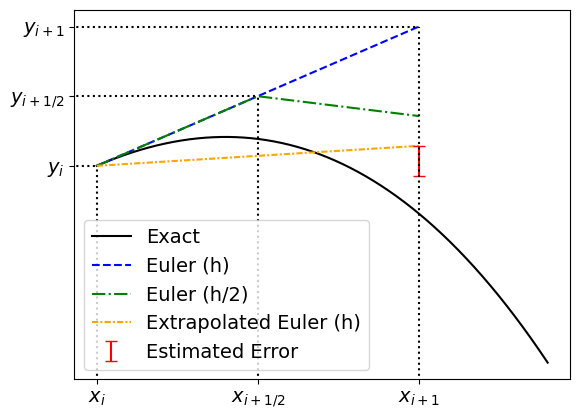

In [43]:
import numpy as np
import matplotlib.pyplot as plt

h = 0.5
xlims = (3, 3.7)

tps = ( 
    (1.2, 1.9), 
    (3.2, 2) )

###Function
def fprime(a, x, y):
    return 3*a[0]*x*x + 2*a[1]*x + a[2]

def f(a,x):
    return a[0]*x*x*x + a[1]*x*x + a[2]*x + a[3]

def sp_to_cubic(sp_xy):
    """
    Construct a cubic polynomial from the stationary points
    """
    X = np.zeros((4,4))
    Y = np.zeros((4,1))
    
    X[::2,0] = 3*sp_xy[:,0]**2
    X[::2,1] = 2*sp_xy[:,0]
    X[::2,2] = 1
    
    X[1::2,0] = sp_xy[:,0]**3
    X[1::2,1] = sp_xy[:,0]**2
    X[1::2,2] = sp_xy[:,0]
    X[1::2,3] = 1
    
    Y[1::2,0] = sp_xy[:,1]
    
    X = np.matrix(X)
    Y = np.matrix(Y)
    return np.array(X.I*Y).flatten()

##Euler
a = sp_to_cubic(np.array(tps))

x_euler = [xlims[0], xlims[0] + h]
y_euler = [f(a, x_euler[0]), 0]

y_euler[1] = y_euler[0] + h*fprime(a, xlims[0], y_euler[0])

x_euler_2 = [xlims[0], xlims[0] + 0.5 * h, xlims[0] + h]
y_euler_2 = [y_euler[0], y_euler[0] + 0.5 * h * fprime(a, xlims[0], y_euler[0])]
y_euler_2 += [y_euler_2[1] + 0.5 * h * fprime(a, xlims[0] + 0.5 * h, y_euler_2[1])]

y_euler_extrap = [y_euler[0], (4 * y_euler_2[-1] - y_euler[-1]) / 3]

x_tick_vals = x_euler_2
x_tick_lbls = [
    r'$x_i$', 
    r'$x_{i+1/2}$', 
    r'$x_{i+1}$'
]

y_tick_vals = (
    y_euler_2[:-1]
    + [y_euler[-1]] 
)
y_tick_lbls = [
    r'$y_i$', 
    r'$y_{i+1/2}$',  
    r'$y_{i+1}$'
]
    
##Plot
x = np.linspace(xlims[0], xlims[1], 1000)    

plt.plot(x, f(a,x), 'k-', label = 'Exact')
plt.plot(x_euler, y_euler, 'b--', label = 'Euler (h)')
plt.plot(x_euler_2, y_euler_2, color='g', ls='dashdot', label = 'Euler (h/2)')
plt.plot(x_euler, y_euler_extrap, color='orange', ls=(0, (3, 1, 1, 1)), label='Extrapolated Euler (h)')

err = y_euler_extrap[-1] - y_euler_2[-1]

plt.errorbar(x_euler[-1], y_euler_extrap[-1] + 0.5 * err, 
             yerr=0.5 * abs(err), color='red', capsize=4,
             ls='',
             label='Estimated Error'
            )

ylim = plt.ylim()
xlim = plt.xlim()

for x_e, y_e in zip(
    x_euler + [x_euler_2[1]], #x_euler_2[1:] + [x_euler[-1]],
    y_euler + [y_euler_2[1]] #y_euler_2[1:] + [y_euler_extrap[-1]]
):
    plt.vlines(x = x_e, ymin = -100, ymax = y_e, color = 'black',
               linestyles = ':')
    plt.hlines(y = y_e, xmin = -100, xmax = x_e, color = 'black',
               linestyles = ':')

plt.ylim(ylim)
plt.xlim(xlim)
plt.xticks(x_tick_vals, x_tick_lbls, fontsize = 14)
plt.yticks(y_tick_vals, y_tick_lbls, fontsize = 14)
plt.legend(fontsize = 14)

plt.show()

<div class="worked-example">
    <p class="worked-example-title">Worked Example</p>

Consider the ODE:

$$
\frac{d y}{dx} = - 2 (x - 1) y
$$

which has the exact solution:

$$
y(x) = e^{- (x - 1)^2 + 1}
$$

Let's solve this ODE from $x = 0$ to $1$ with a step-size of $0.5$ using a single iteration of Richardson extrapolation applied to Euler's method and compare this to the exact solution.

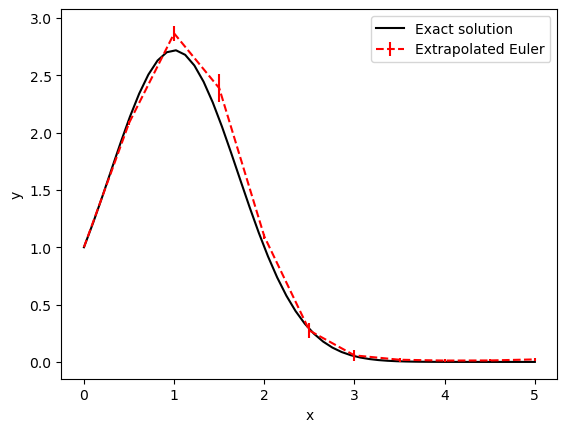

In [48]:
import numpy as np
import matplotlib.pyplot as plt

x0, y0 = 0, 1
h = 0.5
x_end = 5

#The ODE function
def f(x,y):
    return -2 * (x - 1) * y

def y_exact(x):
    return np.exp( -(x - 1)**2 + 1 )


x_extrap = np.arange(x0, x_end + h, h)
y_extrap = np.zeros(x_extrap.size)
y_extrap[0] = y0
e_extrap = np.zeros(x_extrap.size)
#Note there is no error estimate for (x0, y0)
e_extrap[0] = 0

for i, x in enumerate(x_extrap[:-1]):
    #Euler step
    y_h =  y_extrap[i] + h * f(x, y_extrap[i])

    #Half-euler step
    y_h2 = y_extrap[i] + 0.5 * h * f(x, y_extrap[i])
    y_h2 = y_h2 + 0.5 * h * f(x + 0.5 * h, y_h2)

    #Extrapolation
    y_extrap[i+1] = (4 * y_h2 - y_h) / 3
    e_extrap[i+1] = y_extrap[i+1] - y_h2

#Plotting the solution
x_plot = np.linspace(x0, x_end)
fig, ax = plt.subplots()

ax.plot(x_plot, y_exact(x_plot), 'k-', label = 'Exact solution')
ax.errorbar(x_extrap, y_extrap, yerr=np.abs(e_extrap), 
            ls='--', color='red', label='Extrapolated Euler')
ax.set_xlabel('x')
ax.set_ylabel('y')

ax.legend()

plt.show()

</div>